In [4]:
import numpy as np 
import matplotlib.pyplot as plt 
import networkx as nx 
import graph_tool.all as gt 
import os
import sys
sys.path.append('/Users/glover.co/Documents/laszlo/NetDesign/scripts')
import assembly_tree as at
sys.path.append('/Users/glover.co/Documents/laszlo/NetDesign/scripts')
import mcmc
import pandas as pd

In [19]:
prot_num = 1300
mol_num = 196
ikea_num = 102 

In [20]:
files = os.listdir('../data/circuits/ltspice_demos/edgefiles')
Xfiles = os.listdir('../data/circuits/ltspice_demos/Xfiles')
graphs = []
Xs = []
for f in files:
    if f.endswith('.edge'):
        g = nx.read_edgelist(os.path.join('../data/circuits/ltspice_demos/edgefiles', f),nodetype=int)
        graphs.append(g)
        X = np.loadtxt(os.path.join('../data/circuits/ltspice_demos/Xfiles', 'X_' + f.replace('.edge', '.txt')))
        Xs.append(X)


In [21]:
num_edges = [g.number_of_edges() for g in graphs]

In [22]:
max(num_edges)

121

In [23]:
X = Xs[19]
g = graphs[19]
O = at.extract_O(g,X)
capacity = at.extract_deg_cap(g,X).reshape(-1)

In [24]:
initial_graph = nx.Graph()
initial_graph.add_nodes_from(g.nodes())
at.prob_dist(X,O,capacity,T = 1000,initial_graph = initial_graph,rewire_est=True,max_edges=True)
# res = at.find_optimal_edge_count(X,O,capacity,initial_graph)

(array([69, 31]),
 array([0, 1]),
 True)

In [25]:
res.x

NameError: name 'res' is not defined

In [15]:
at.microcanonical_ensemble(X,O,capacity,initial_graph=initial_graph,T=1000)

In [32]:
np.argmax(num_edges)*2
nodes = initial_graph.nodes()

In [34]:
deg = initial_graph.degree()
X[nodes,:]@capacity - np.array([deg[i] for i in nodes])

array([[2., 2., 2., ..., 2., 2., 2.],
       [5., 5., 5., ..., 5., 5., 5.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [2., 2., 2., ..., 2., 2., 2.],
       [1., 1., 1., ..., 1., 1., 1.]])

In [22]:
protein_sp = np.loadtxt('../data/proteins/specificity.txt')
molecule_sp = np.loadtxt('../data/molecules/specificity.txt')
robots_sp = np.loadtxt('../data/robots/specificity.txt')
circuit_sp = np.loadtxt('../data/circuits/specificity.txt')
ikea_sp = np.loadtxt('../data/IkeaData/specificity.txt')

In [51]:
prot_y, prot_x = np.histogram(protein_sp, bins=40, range=(0,1))
mol_y, mol_x = np.histogram(molecule_sp, bins=40, range=(0,1))
ikea_y, ikea_x = np.histogram(ikea_sp, bins=40, range=(0,1))
circuit_y, circuit_x = np.histogram(circuit_sp, bins=40, range=(0,1))
robot_y, robot_x = np.histogram(robots_sp, bins=40, range=(0,1))
prot_y = prot_y / np.sum(prot_y)
mol_y = mol_y / np.sum(mol_y)
ikea_y = ikea_y / np.sum(ikea_y)
circuit_y = circuit_y / np.sum(circuit_y)
robot_y = robot_y / np.sum(robot_y)


In [52]:
prot_x = (prot_x[:-1] + prot_x[1:]) / 2
mol_x = (mol_x[:-1] + mol_x[1:]) / 2
ikea_x = (ikea_x[:-1] + ikea_x[1:]) / 2
circuit_x = (circuit_x[:-1] + circuit_x[1:]) / 2
robot_x = (robot_x[:-1] + robot_x[1:]) / 2


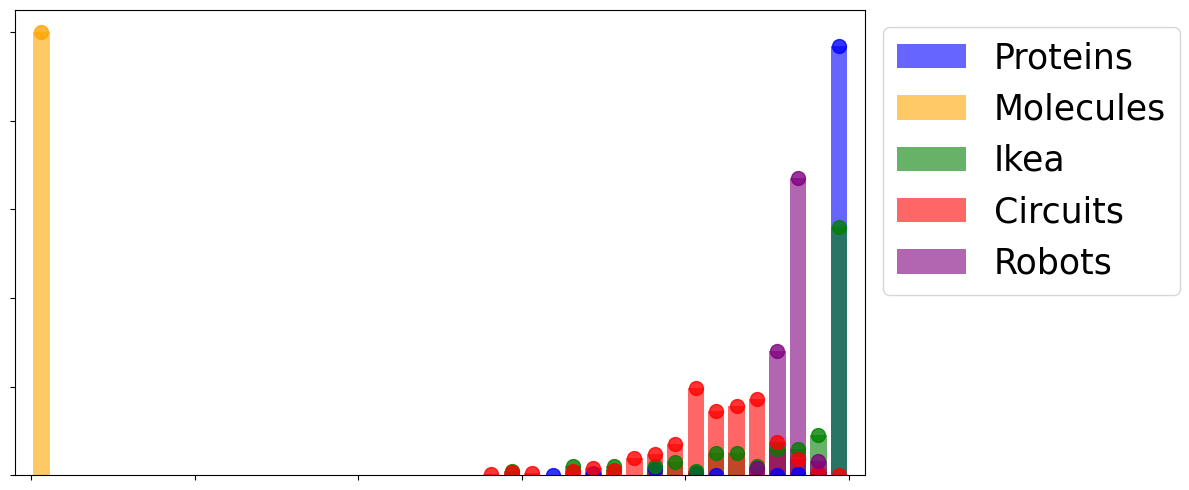

In [60]:
plt.figure(figsize=(12, 5))

# Filter and plot bars for Proteins
non_zero_prot = prot_y > 0
plt.bar(prot_x[non_zero_prot], prot_y[non_zero_prot], width=0.02, label='Proteins', color='blue', alpha=0.6)

# Filter and plot bars for Molecules
non_zero_mol = mol_y > 0
plt.bar(mol_x[non_zero_mol], mol_y[non_zero_mol], width=0.02, label='Molecules', color='orange', alpha=0.6)

# Filter and plot bars for Ikea
non_zero_ikea = ikea_y > 0
plt.bar(ikea_x[non_zero_ikea], ikea_y[non_zero_ikea], width=0.02, label='Ikea', color='green', alpha=0.6)

# Filter and plot bars for Circuits
non_zero_circuit = circuit_y > 0
plt.bar(circuit_x[non_zero_circuit], circuit_y[non_zero_circuit], width=0.02, label='Circuits', color='red', alpha=0.6)

# Filter and plot bars for Robots
non_zero_robot = robot_y > 0
plt.bar(robot_x[non_zero_robot], robot_y[non_zero_robot], width=0.02, label='Robots', color='purple', alpha=0.6)

# Add dots at the top of the bars
plt.scatter(prot_x[non_zero_prot], prot_y[non_zero_prot], color='blue', s=100, alpha=0.8)
plt.scatter(mol_x[non_zero_mol], mol_y[non_zero_mol], color='orange', s=100, alpha=0.8)
plt.scatter(ikea_x[non_zero_ikea], ikea_y[non_zero_ikea], color='green', s=100, alpha=0.8)
plt.scatter(circuit_x[non_zero_circuit], circuit_y[non_zero_circuit], color='red', s=100, alpha=0.8)
plt.scatter(robot_x[non_zero_robot], robot_y[non_zero_robot], color='purple', s=100, alpha=0.8)

plt.xticks(ticks=plt.xticks()[0], labels=[])
plt.yticks(ticks=plt.yticks()[0], labels=[])
plt.xlim(-.02, 1.02)
plt.ylim(0, 1.05)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=25)
plt.tight_layout()
plt.savefig('/Users/glover.co/CCNR Dropbox/Success Team/Glover, Cory/network_design/drafts/Network-Design-March-2025-/v10/figs/specificity_distributions.png', bbox_inches='tight', dpi=300)
plt.show()


In [61]:
ikea_sp[30]

np.float64(1.0)

In [72]:
np.min(protein_sp[protein_sp>0])

np.float64(0.625)

In [73]:
np.where(protein_sp == 0.625)

(array([316]),)

In [4]:
protein_sa = np.loadtxt('../data/proteins/sa.txt')
molecule_sa = np.loadtxt('../data/molecules/sa.txt')
robots_sa = np.loadtxt('../data/robots/sa.txt')
circuit_sa = np.loadtxt('../data/circuits/sa.txt')
ikea_sa = np.loadtxt('../data/IkeaData/sa.txt')

In [7]:
mol_names = []
with open('../params/molecules/mcmc_params.txt', 'r') as f:
    for line in f:
        mol_names.append(line.strip())

In [12]:
len('--graph_file /scratch/glover.co/NetDesign/data/molecules/WHO/edgefiles/')
mol_list = [m[71:].split(' ') for m in mol_names]
mol_list = [m[0] for m in mol_list]
mol_list = [m.replace('.edge','') for m in mol_list]
mol_list

['CID_10112',
 'CID_11029',
 'CID_11248',
 'CID_119432',
 'CID_165565',
 'CID_168924',
 'CID_17358',
 'CID_23665760',
 'CID_23668193',
 'CID_23668197',
 'CID_24083',
 'CID_24243',
 'CID_24266',
 'CID_24393',
 'CID_24424',
 'CID_24436',
 'CID_24439',
 'CID_24456',
 'CID_24462',
 'CID_24470',
 'CID_24934',
 'CID_25960',
 'CID_280',
 'CID_3032553',
 'CID_4101',
 'CID_445709',
 'CID_516900',
 'CID_5453',
 'CID_56955933',
 'CID_5702198',
 'CID_61745',
 'CID_6212',
 'CID_6374',
 'CID_64655',
 'CID_679',
 'CID_727',
 'CID_7628',
 'CID_76957057',
 'CID_784',
 'CID_10103319',
 'CID_10221470',
 'CID_1031',
 'CID_1046',
 'CID_11024312',
 'CID_1116159',
 'CID_1116160',
 'CID_11333',
 'CID_11358077',
 'CID_115056',
 'CID_11832956',
 'CID_118705487',
 'CID_122173797',
 'CID_12620',
 'CID_12675',
 'CID_131704316',
 'CID_131839611',
 'CID_132477936',
 'CID_132935795',
 'CID_13916',
 'CID_14052',
 'CID_14250',
 'CID_14251',
 'CID_146157093',
 'CID_154701625',
 'CID_157355',
 'CID_16058',
 'CID_16098',


In [19]:
sa_mol = [m for m in mol_list if molecule_sa[mol_list.index(m)] == 1]
sa_mol
np.savetxt('../data/sa_mol.txt', sa_mol, fmt='%s')

In [103]:
prot_max_div = np.loadtxt('../data/proteins/max_diversity.txt')
mol_max_div = np.loadtxt('../data/molecules/max_diversity.txt')
robots_max_div = np.loadtxt('../data/robots/max_diversity.txt')
circuit_max_div = np.loadtxt('../data/circuits/max_diversity.txt')
ikea_max_div = np.loadtxt('../data/IkeaData/max_diversity.txt')
prot_max_div_perc = prot_max_div.sum() / protein_sa[protein_sa > 0].sum()
mol_max_div_perc = mol_max_div.sum() / molecule_sa[molecule_sa > 0].sum()
robots_max_div_perc = robots_max_div.sum() / robots_sa[robots_sa > 0].sum()
circuit_max_div_perc = circuit_max_div.sum() / circuit_sa[circuit_sa > 0].sum()
ikea_max_div_perc = ikea_max_div.sum() / ikea_sa[ikea_sa > 0].sum()

/var/folders/8t/4z1vq2xd5790h0y5jrvphttr0000gp/T/ipykernel_14570/3005731854.py:8: RuntimeWarning: divide by zero encountered in scalar divide
  robots_max_div_perc = robots_max_div.sum() / robots_sa[robots_sa > 0].sum()


In [104]:
prot_sa_y, prot_sa_x = np.histogram(protein_sa, bins=2, range=(0,1))
mol_sa_y, mol_sa_x = np.histogram(molecule_sa, bins=2, range=(0,1))
ikea_sa_y, ikea_sa_x = np.histogram(ikea_sa, bins=2, range=(0,1))
circuit_sa_y, circuit_sa_x = np.histogram(circuit_sa, bins=2, range=(0,1))
robot_sa_y, robot_sa_x = np.histogram(robots_sa, bins=2, range=(0,1))
prot_sa_y = prot_sa_y / np.sum(prot_sa_y)
mol_sa_y = mol_sa_y / np.sum(mol_sa_y)
ikea_sa_y = ikea_sa_y / np.sum(ikea_sa_y)
circuit_sa_y = circuit_sa_y / np.sum(circuit_sa_y)
robot_sa_y = robot_sa_y / np.sum(robot_sa_y)

In [105]:
prot_sa_x = (prot_sa_x[:-1] + prot_sa_x[1:]) / 2
mol_sa_x = (mol_sa_x[:-1] + mol_sa_x[1:]) / 2
ikea_sa_x = (ikea_sa_x[:-1] + ikea_sa_x[1:]) / 2
circuit_sa_x = (circuit_sa_x[:-1] + circuit_sa_x[1:]) / 2
robot_sa_x = (robot_sa_x[:-1] + robot_sa_x[1:]) / 2

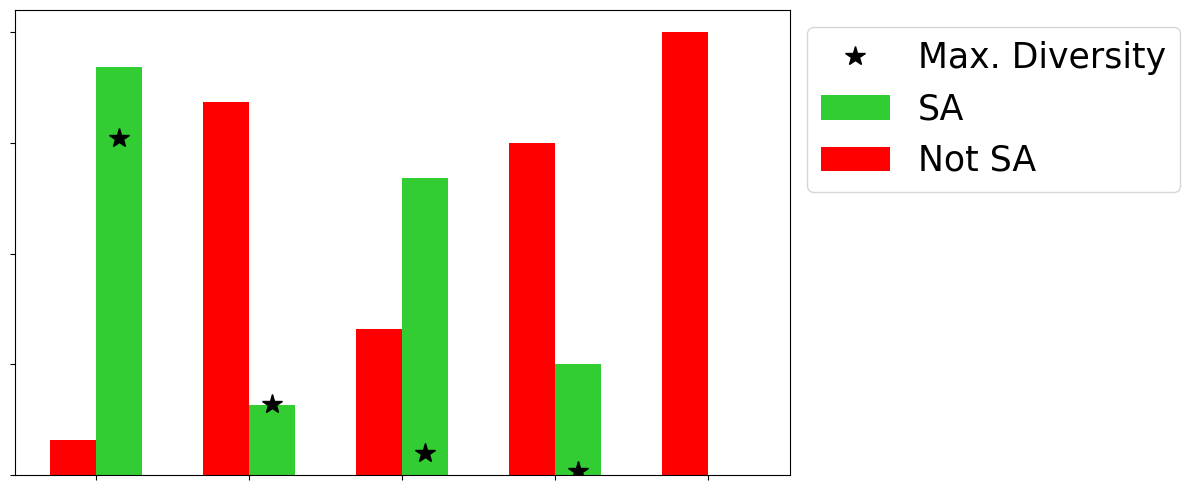

In [118]:
plt.figure(figsize=(12, 5))
# Make bar plots for each dataset side by side
plt.bar(.3, prot_sa_y[1], width=0.3, color='#32CD32', label='SA', alpha=1)
plt.bar(0, prot_sa_y[0], width=0.3, label='Not SA', color='red', alpha=1)
plt.bar(1, mol_sa_y[0], width=0.3, color='red', alpha=1)
plt.bar(1.3, mol_sa_y[1], width=0.3, color='#32CD32', alpha=1)
plt.bar(2, ikea_sa_y[0], width=0.3, color='red', alpha=1)
plt.bar(2.3, ikea_sa_y[1], width=0.3, color='#32CD32', alpha=1)
plt.bar(3, circuit_sa_y[0], width=0.3, color='red', alpha=1)
plt.bar(3.3, circuit_sa_y[1], width=0.3, color='#32CD32', alpha=1)
plt.bar(4, robot_sa_y[0], width=0.3, color='red', alpha=1)
plt.bar(4.3, robot_sa_y[1], width=0.3, color='#32CD32', alpha=1)
plt.plot(.3, prot_max_div_perc, '*', color='black', markersize=15, label='Max. Diversity') 
plt.plot(1.3, mol_max_div_perc, '*', color='black', markersize=15)
plt.plot(2.3, ikea_max_div_perc, '*', color='black', markersize=15)
plt.plot(3.3, circuit_max_div_perc, '*', color='black', markersize=15)
plt.plot(4.3, robots_max_div_perc, '*', color='black', markersize=15)
plt.xticks([0.15, 1.15, 2.15, 3.15, 4.15], ['', '', '', '', ''])
plt.yticks(ticks=[0,.25,.5,.75,1.0], labels=[])
# plt.ylabel('Percentage of Self-Assembly')
plt.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=25)
plt.tight_layout()
plt.savefig('/Users/glover.co/CCNR Dropbox/Success Team/Glover, Cory/network_design/drafts/Network-Design-March-2025-/v10/figs/self_assembly.pdf', bbox_inches='tight', dpi=300)


In [ ]:
prot_max_div = np.loadtxt('../data/proteins/max_diversity.txt')
mol_max_div = np.loadtxt('../data/molecules/max_diversity.txt')
robots_max_div = np.loadtxt('../data/robots/max_diversity.txt')
circuit_max_div = np.loadtxt('../data/circuits/max_diversity.txt')
ikea_max_div = np.loadtxt('../data/IkeaData/max_diversity.txt')
prot_max_div_perc = prot_max_div.sum() / 

In [101]:
prot_max_div.sum()

np.float64(851.0)

In [20]:
import pickle

In [100]:
with open('/Users/glover.co/Downloads/PGER.pkl', 'rb') as f:
    PGER = pickle.load(f)
with open('/Users/glover.co/Downloads/PGCM.pkl', 'rb') as f:
    PGCM = pickle.load(f)
with open('/Users/glover.co/Downloads/PGBA.pkl', 'rb') as f:
    PGBA = pickle.load(f)
with open('/Users/glover.co/Downloads/PGSB.pkl', 'rb') as f:
    PGSB = pickle.load(f)
with open('/Users/glover.co/Downloads/PGDCSBM_gt.pkl', 'rb') as f:
    PGDCSBM_gt = pickle.load(f)

In [213]:
g = PGDCSBM_gt[1][np.argmax(PGDCSBM_gt[0])]
edges = [(g.vertex_index[e.source()],g.vertex_index[e.target()]) for e in g.edges()]
edges

[(0, 5),
 (0, 6),
 (0, 8),
 (1, 3),
 (1, 9),
 (2, 3),
 (2, 4),
 (3, 4),
 (3, 9),
 (5, 1),
 (5, 8),
 (6, 8),
 (6, 9),
 (7, 8),
 (7, 4)]

/var/folders/8t/4z1vq2xd5790h0y5jrvphttr0000gp/T/ipykernel_67728/642480983.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


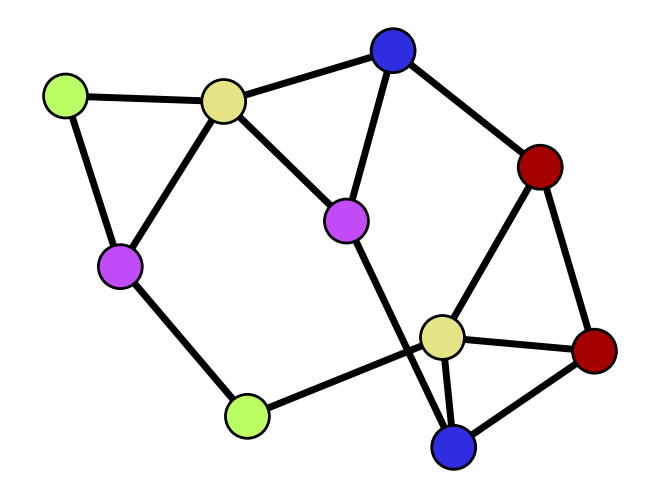

[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


In [214]:
target = nx.read_edgelist('../data/proteins/human/edgefiles/CPX-8343.edge',nodetype=int)
X = np.loadtxt('../data/proteins/human/Xfiles/X_CPX-8343.txt')
# Add edge weight
# g = PGSB[1][np.argmin(PGSB[0])]
g = nx.Graph()
g.add_nodes_from(target.nodes())
g.add_edges_from(edges)
for u, v in g.edges():
    g[u][v]['weight'] = 5.0
color_map = {0: np.array([166,0,0])/256, 1: np.array([46,46,225])/256, 3: np.array([229,229,135])/256, 4: np.array([194,75,247])/256, 2: np.array([187, 255, 99])/256}
colors = [color_map[np.argmax(X[int(node)])] for node in target.nodes()]
pos = nx.kamada_kawai_layout(g)
at.draw_network(g,X,node_size=1000,pos=pos,linewidths=2,edgecolors='k',with_labels=False,colors=colors)
plt.tight_layout()
plt.savefig('figs/dcsbm_network_1.png', dpi=300)
plt.show()
print(X)

In [149]:
target_gt = gt.Graph(directed=False)
target_gt.add_vertex(len(target.nodes()))
target_gt.add_edge_list(target.edges())

Found ER isomorphic graph at idx 12375


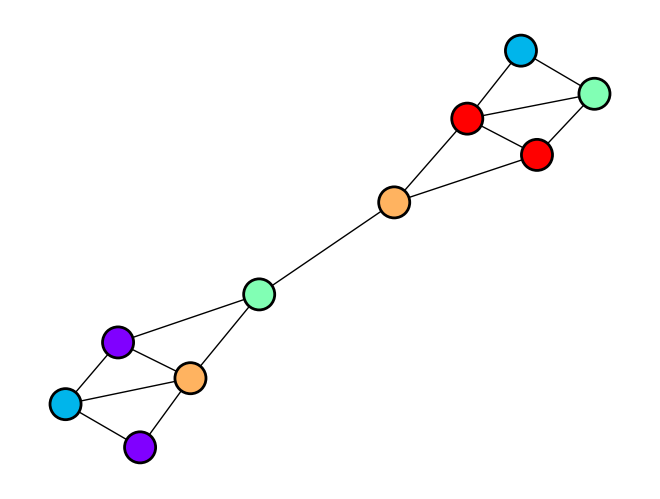

Found CM isomorphic graph at idx 831


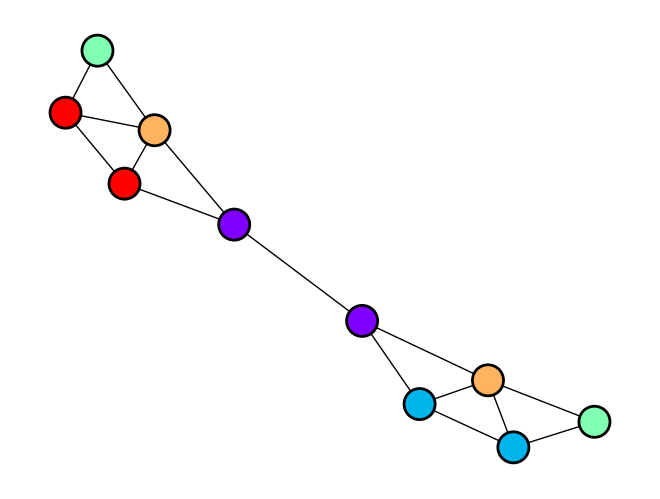

Found SB isomorphic graph at idx 0


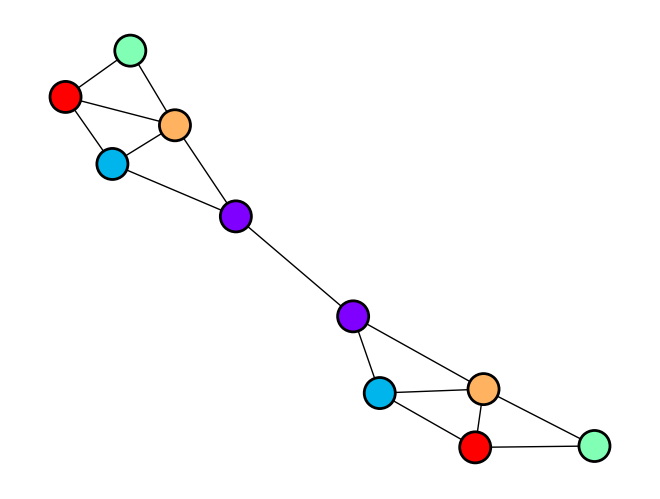

Found DCSBM_gt isomorphic graph at idx 64


In [150]:
for i, g in enumerate(PGER[1]):
    if nx.is_isomorphic(g, target):
        print(f'Found ER isomorphic graph at idx {i}')
        at.draw_network(g, X, node_size=500,linewidths=2,edgecolors='k')
        plt.show()
for i, g in enumerate(PGCM[1]):
    if nx.is_isomorphic(g, target):
        print(f'Found CM isomorphic graph at idx {i}')
        at.draw_network(g, X, node_size=500,linewidths=2,edgecolors='k')
        plt.show()
for i, g in enumerate(PGBA[1]):
    if nx.is_isomorphic(g, target):
        print(f'Found BA isomorphic graph at idx {i}')
        at.draw_network(g, X, node_size=500,linewidths=2,edgecolors='k')
        plt.show()
for i, g in enumerate(PGSB[1]):
    if nx.is_isomorphic(g, target):
        print(f'Found SB isomorphic graph at idx {i}')
        at.draw_network(g, X, node_size=500,linewidths=2,edgecolors='k')
        plt.show()
for i, g in enumerate(PGDCSBM_gt[1]):
    if gt.isomorphism(g, target_gt):
        print(f'Found DCSBM_gt isomorphic graph at idx {i}')


In [138]:
np.where(np.argsort(PGER[0]) == 12375)[0][0]

35133

<Figure size 500x500 with 0 Axes>

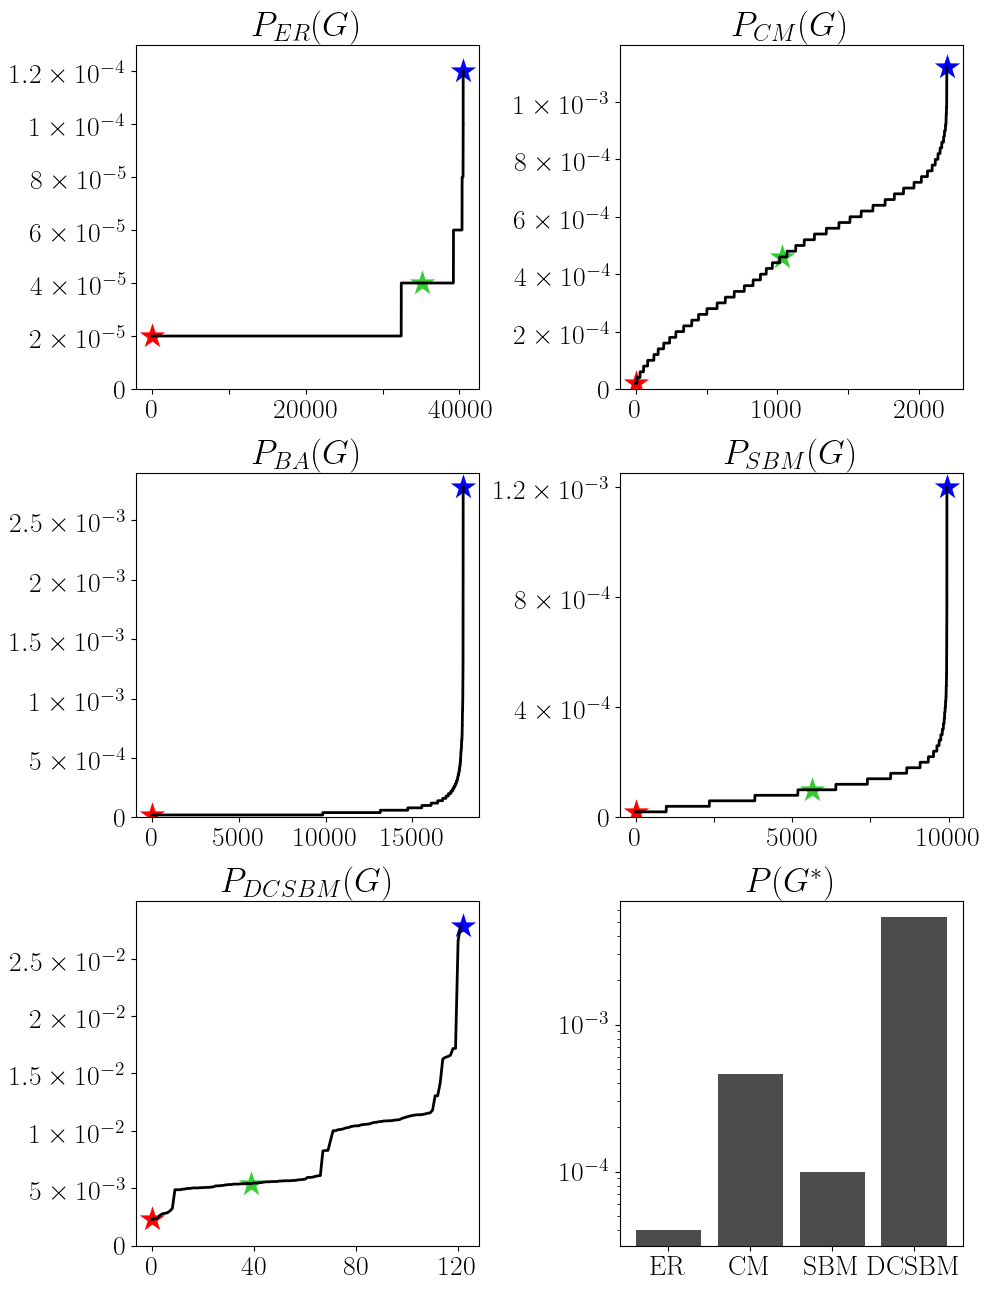

In [170]:
csfont = {'fontname':'Times New Roman'}
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times New Roman']})
rc('text', usetex=True)
fig = plt.figure(figsize=(5, 5))
fig, axs = plt.subplots(3,2,figsize=(10,13))
axs[0,0].plot(sorted(PGER[0])/np.sum(PGER[0]), color='k', linewidth=2, label='PGER',alpha=1)
axs[0,0].scatter(0, (sorted(PGER[0])/np.sum(PGER[0]))[0], marker='*', color='r', s=500, label='PGER', edgecolors='w')  # Increased size
axs[0,0].scatter(len(PGER[0]), (sorted(PGER[0])/np.sum(PGER[0]))[-1], marker='*', color='b', s=500, edgecolors='w')  # Increased size
axs[0,0].scatter(np.where(np.argsort(PGER[0]) == 12375)[0][0], ((PGER[0])/np.sum(PGER[0]))[12375], marker='*', color='limegreen', s=500, edgecolors='w')  # Increased size
axs[0,0].set_ylim(0,.00013)
axs[0,0].set_yticks(ticks=[0,.00002,.00004,.00006,.00008,.0001,.00012], labels=['0',r'$2\times 10^{-5}$', r'$4\times 10^{-5}$', r'$6\times 10^{-5}$', r'$8\times 10^{-5}$', r'$1\times 10^{-4}$', r'$1.2\times 10^{-4}$'],fontsize=20)
axs[0,0].set_xticks(ticks=[0,10000,20000,30000,40000], labels=['0', '', '20000', '', '40000'], fontsize=20)
axs[0,0].set_title(r'$P_{ER}(G)$', fontsize=25)
axs[0,1].plot(sorted(PGCM[0])/np.sum(PGCM[0]), color='k', linewidth=2, label='PGCM',alpha=1)
axs[0,1].scatter(0, (sorted(PGCM[0])/np.sum(PGCM[0]))[0], marker='*', color='r', s=500, label='PGCM', edgecolors='w')  # Increased size
axs[0,1].scatter(len(PGCM[0]), (sorted(PGCM[0])/np.sum(PGCM[0]))[-1], marker='*', color='b', s=500, edgecolors='w')  # Increased size
axs[0,1].scatter(np.where(np.argsort(PGCM[0])==831)[0][0], ((PGCM[0])/np.sum(PGCM[0]))[831], marker='*', color='limegreen', s=500, edgecolors='w')  # Increased size
axs[0,1].set_ylim(0,.0012)
axs[0,1].set_yticks(ticks=[0,.0002,.0004,.0006,.0008,0.001], labels=['0',r'$2\times 10^{-4}$', r'$4\times 10^{-4}$', r'$6\times 10^{-4}$', r'$8\times 10^{-4}$', r'$1\times 10^{-3}$'],fontsize=20)
axs[0,1].set_xticks(ticks=[0,500,1000,1500,2000], labels=['0', '', '1000', '', '2000'], fontsize=20)
axs[0,1].set_title(r'$P_{CM}(G)$', fontsize=25)
axs[1,0].plot(sorted(PGBA[0])/np.sum(PGBA[0]), color='k', linewidth=2, label='PGBA',alpha=1)
axs[1,0].scatter(0, (sorted(PGBA[0])/np.sum(PGBA[0]))[0], marker='*', color='r', s=500, label='PGBA', edgecolors='w')  # Increased size
axs[1,0].scatter(len(PGBA[0]), (sorted(PGBA[0])/np.sum(PGBA[0]))[-1], marker='*', color='b', s=500, edgecolors='w')  # Increased size
axs[1,0].set_ylim(0,.0029)
axs[1,0].set_yticks(ticks=[0,.0005,.001,.0015,.002,.0025], labels=['0',r'$5\times 10^{-4}$', r'$1\times 10^{-3}$', r'$1.5\times 10^{-3}$', r'$2\times 10^{-3}$', r'$2.5\times 10^{-3}$'],fontsize=20)
axs[1,0].set_xticks(ticks=[0,5000,10000,15000], labels=['0', '5000', '10000', '15000'], fontsize=20)
axs[1,0].set_title(r'$P_{BA}(G)$', fontsize=25)
axs[1,1].plot(sorted(PGSB[0])/np.sum(PGSB[0]), color='k', linewidth=2, label='PGSB',alpha=1)
axs[1,1].scatter(0, (sorted(PGSB[0])/np.sum(PGSB[0]))[0], marker='*', color='r', s=500, label='PGSB', edgecolors='w')  # Increased size
axs[1,1].scatter(len(PGSB[0]), (sorted(PGSB[0])/np.sum(PGSB[0]))[-1], marker='*', color='b', s=500, edgecolors='w')  # Increased size
axs[1,1].scatter(np.where(np.argsort(PGSB[0])==0)[0][0], ((PGSB[0])/np.sum(PGSB[0]))[0], marker='*', color='limegreen', s=500, edgecolors='w')  # Increased size
axs[1,1].set_ylim(0,.00125)
axs[1,1].set_yticks(ticks=[0,.0004,.0008,0.0012], labels=['0', r'$4\times 10^{-4}$', r'$8\times 10^{-4}$', r'$1.2\times 10^{-3}$'],fontsize=20)
axs[1,1].set_xticks(ticks=[0,2500,5000,7500,10000], labels=['0', '', '5000', '', '10000'], fontsize=20)
axs[1,1].set_title(r'$P_{SBM}(G)$', fontsize=25)
axs[2,0].plot(sorted(PGDCSBM_gt[0])/np.sum(PGDCSBM_gt[0]), color='k', linewidth=2, label='PGDCSBM_gt',alpha=1)
axs[2,0].scatter(0, (sorted(PGDCSBM_gt[0])/np.sum(PGDCSBM_gt[0]))[0], marker='*', color='r', s=500, label='PGDCSBM_gt', edgecolors='w')  # Increased size
axs[2,0].scatter(len(PGDCSBM_gt[0]), (sorted(PGDCSBM_gt[0])/np.sum(PGDCSBM_gt[0]))[-1], marker='*', color='b', s=500, edgecolors='w')  # Increased size
axs[2,0].scatter(np.where(np.argsort(PGDCSBM_gt[0])==64)[0][0], ((PGDCSBM_gt[0])/np.sum(PGDCSBM_gt[0]))[64], marker='*', color='limegreen', s=500, edgecolors='w')  # Increased size
axs[2,0].set_ylim(0,.03)
axs[2,0].set_yticks(ticks=[0,.005,.01,.015,.02,.025], labels=['0', r'$5\times 10^{-3}$', r'$1\times 10^{-2}$', r'$1.5\times 10^{-2}$', r'$2\times 10^{-2}$', r'$2.5\times 10^{-2}$'],fontsize=20)
axs[2,0].set_xticks(ticks=[0,40,80,120], labels=['0', '40', '80', '120'], fontsize=20)
axs[2,0].set_title(r'$P_{DCSBM}(G)$', fontsize=25)
axs[2,1].bar([0,1,2,3],[PGER[0][12375]/np.sum(PGER[0]), PGCM[0][831]/np.sum(PGCM[0]), PGSB[0][0]/np.sum(PGSB[0]), PGDCSBM_gt[0][64]/np.sum(PGDCSBM_gt[0])], color=['k','k','k','k'], alpha=0.7)
axs[2,1].set_xticks([0,1,2,3], labels=[r'ER', r'CM', r'SBM', r'DCSBM'], fontsize=20)
# Make font of yticks size 20
axs[2,1].set_yticks(ticks=[1e-6,1e-5,1e-4,1e-3], labels=[r'$10^{-6}$', r'$10^{-5}$', r'$10^{-4}$', r'$10^{-3}$'], fontsize=20)
axs[2,1].set_yscale('log')
axs[2,1].set_title(r'$P(G^*)$', fontsize=25)
# Add padding between plots
fig.tight_layout()
plt.savefig('/Users/glover.co/CCNR Dropbox/Success Team/Glover, Cory/network_design/drafts/Network-Design-March-2025-/v10/figs/probability_distributions.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [59]:
ikea_df = pd.read_csv('../stats/Ikea/newer_assembly_stats.csv',index_col=False)
protein_df = pd.read_csv('../stats/proteins/newer_assembly_stats.csv',index_col=False)
molecule_df = pd.read_csv('../stats/molecules/newer_assembly_stats.csv',index_col=False)
robot_df = pd.read_csv('../stats/robots/newer_assembly_stats.csv',index_col=False)
circuit_df = pd.read_csv('../stats/circuits/assembly_stats.csv',index_col=False)

In [60]:
circuit_df

,name,subdir,N,E,N_types,specificity,degree_mean,degree_hetero,max_edges,clustering_coeff,max_chordless_cycle,self_assembly_probability,tree_num,guided_assembly_probability,tree_depth,tree_leaves,tree_N
0,LTC6090_LTC2054_DN513_F02_,ltspice_demos,56,63,25,0.886161,2.250000,6.928571,63,0.038690,12,False,0.0,0.001,1.0,26.0,27.0
1,LT1964_DC437,ltspice_demos,17,18,11,0.815686,2.117647,6.000000,18,0.070588,4,True,0.0,1.000,0.0,1.0,1.0
2,LT3509,ltspice_demos,24,27,16,0.840741,2.250000,8.000000,27,0.099537,4,True,0.0,1.000,0.0,1.0,1.0
3,LTC6362_LTC5599_Baseband_IQModulator,ltspice_demos,58,66,25,0.897510,2.275862,6.965517,66,0.000000,16,False,NaN,NaN,NaN,NaN,NaN
4,LTC6993_TA10_LTC6994_,ltspice_demos,52,55,18,0.720965,2.115385,6.500000,55,0.008974,4,False,0.0,0.010,1.0,42.0,43.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,ADA4661-2,ltspice_examples,14,14,7,0.803571,2.000000,5.142857,14,0.000000,4,True,NaN,NaN,NaN,NaN,NaN
161,AD8628,ltspice_examples,14,14,7,0.803571,2.000000,5.142857,14,0.000000,4,True,NaN,NaN,NaN,NaN,NaN
162,1637,ltspice_examples,16,18,11,0.910417,2.250000,6.750000,18,0.045833,5,False,NaN,NaN,NaN,NaN,NaN
163,ADM7155-01,ltspice_examples,22,23,9,0.728220,2.090909,6.545455,23,0.062229,4,False,NaN,NaN,NaN,NaN,NaN


In [2]:
g = nx.read_edgelist('../data/circuits/ltspice_demos/edgefiles/LTC6090_LTC2054_DN513_F02_.edge', nodetype=int, create_using=nx.Graph)
# g = nx.fast_gnp_random_graph(10,.1)
g.edges()

EdgeView([(0, 28), (0, 43), (28, 7), (28, 8), (1, 29), (1, 44), (29, 21), (29, 23), (2, 30), (2, 45), (30, 21), (30, 26), (3, 31), (3, 32), (31, 11), (31, 13), (31, 16), (31, 19), (31, 20), (32, 4), (32, 5), (32, 21), (4, 46), (5, 33), (33, 19), (33, 21), (6, 34), (6, 35), (6, 36), (6, 37), (6, 38), (34, 8), (34, 17), (35, 9), (35, 10), (35, 16), (35, 18), (36, 15), (36, 18), (37, 22), (37, 23), (37, 24), (38, 25), (38, 26), (38, 27), (7, 47), (9, 48), (10, 39), (39, 11), (39, 12), (39, 14), (12, 14), (13, 40), (15, 21), (21, 41), (21, 42), (21, 51), (17, 49), (20, 50), (22, 52), (24, 53), (25, 54), (27, 55)])

In [62]:
max([len(cycle) for cycle in nx.chordless_cycles(g)])

12

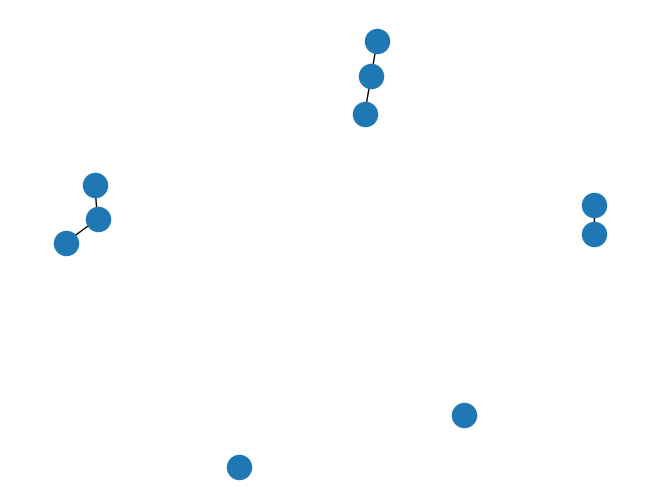

In [57]:
nx.draw(g)

In [59]:
list(nx.chordless_cycles(g)) == []

True

In [29]:
g = nx.read_edgelist('../data/circuits/ltspice_demos/edgefiles/LTM8047_DC1693A.edge', nodetype=int, create_using=nx.Graph)
X = np.loadtxt('../data/circuits/ltspice_demos/Xfiles/X_LTM8047_DC1693A.txt')
# g = nx.read_edgelist('../data/proteins/human/edgefiles/CPX-5774.edge', nodetype=int, create_using=nx.Graph)
# X = np.loadtxt('../data/proteins/human/Xfiles/X_CPX-5774.txt')
if X.ndim == 1:
    X = X.reshape(len(X),1)
O = at.extract_O(g, X)
capacity = at.extract_deg_cap(g, X).reshape(-1)
initial_graph = nx.Graph()
initial_graph.add_nodes_from(np.arange(X.shape[0]))

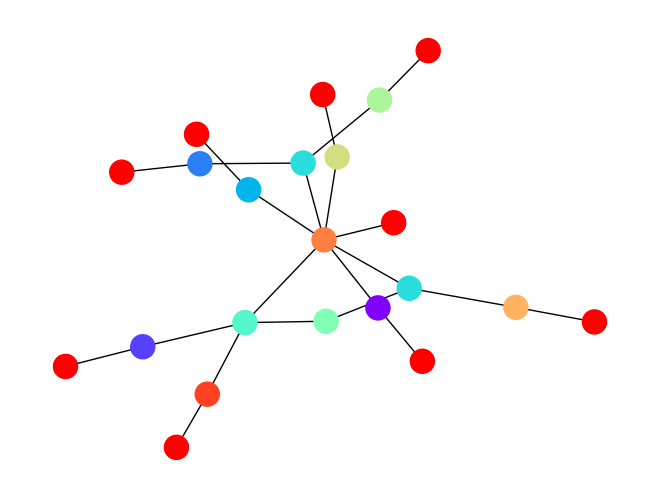

In [31]:
at.draw_network(g, X)

In [23]:
val = at.self_assembly(X, O, capacity, initial_graph)
print(val)

KeyboardInterrupt: 

In [6]:
sol, edges = at.find_optimal_edge_count(X, O, capacity, initial_graph=initial_graph, solution=True, ret_edges=True)
    # if sol is None:
    #     return False
solutions = [sol]
edge_lists = [edges]
# Check whether another solution exists
new_sol = True
while new_sol is not None:
    new_sol, new_edges = at.find_optimal_edge_count(X, O, capacity, old_sol=solutions, initial_graph=initial_graph, solution=True, ret_edges=True)
    # Check whether new_sol has right amount of edges
    if len(new_edges) < len(edge_lists[0]):
        break

    g = nx.Graph()
    g.add_nodes_from(initial_graph.nodes())
    g.add_edges_from(new_edges)
    # Check whether isomorphic
    for i in range(len(edge_lists)):
        h = nx.Graph()
        h.add_nodes_from(initial_graph.nodes())
        h.add_edges_from(edge_lists[i])
        if not nx.is_isomorphic(g,h):
            print('Not Isomorphic')
    solutions.append(new_sol)
    edge_lists.append(new_edges)

In [33]:
edges, initial_graph.nodes(), X[16]

(array([[ 0,  9],
        [ 0, 15],
        [ 1,  2],
        [ 1,  8],
        [ 1,  9],
        [ 1, 10],
        [ 1, 11],
        [ 2, 10],
        [ 3,  9],
        [ 3, 16],
        [ 4,  8],
        [ 4, 14],
        [ 5, 10],
        [ 5, 12],
        [ 6, 10],
        [ 6, 13],
        [ 7,  8],
        [ 7, 10]]),
 NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16)),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]))

True


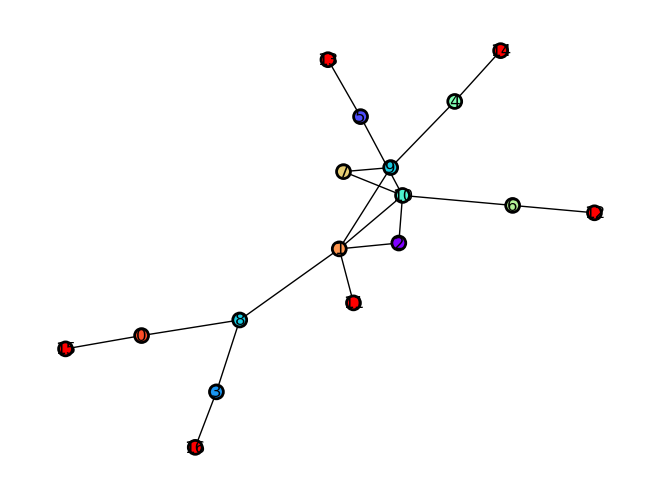

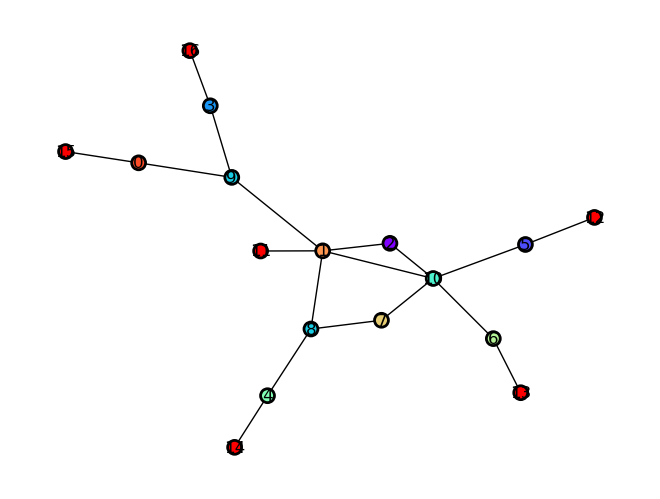

In [13]:
cur_sol = nx.Graph()
cur_sol.add_nodes_from(np.arange(X.shape[0]))
cur_sol.add_edges_from(edge_lists[1])
new_cur_sol = nx.Graph()
new_cur_sol.add_nodes_from(np.arange(X.shape[0]))
new_cur_sol.add_edges_from(edge_lists[0])
print(nx.is_isomorphic(cur_sol, new_cur_sol))
# print(cur_sol.nodes())
at.draw_network(cur_sol, X, node_size=100, linewidths=2, edgecolors='k', with_labels=True)
plt.show()
at.draw_network(new_cur_sol, X, node_size=100, linewidths=2, edgecolors='k', with_labels=True)
plt.show()

In [12]:
len(edge_lists[0])

18

In [ ]:
solutions = [sol]
edges = []
new_sol=True
while new_sol is not None:
    new_sol, new_edges = at.find_optimal_edge_count(X, O, capacity, old_sol=solutions, initial_graph=initial_graph, ret_edges=True)
    if new_sol is not None:
        solutions.append(new_sol)
        edges.append(new_edges)

start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start milp
True
start mi

In [7]:
len(solutions)

595

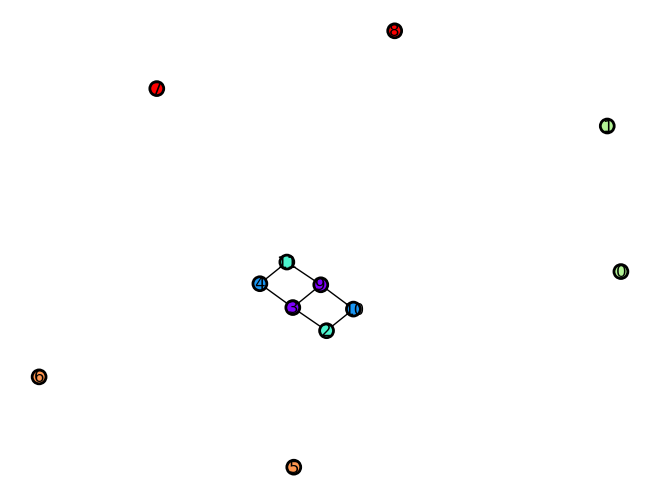

In [ ]:
# for i, s in enumerate(solutions[:10]):
new_g = nx.Graph()
new_g.add_nodes_from(np.arange(X.shape[0]))
new_g.add_edges_from(edge_lists[2])
at.draw_network(new_g, X, node_size=100, linewidths=2, edgecolors='k', with_labels=True)
plt.show()

In [12]:
nx.is_isomorphic(cur_sol, new_g)

False

In [9]:
prot_y, prot_x = np.histogram(protein_df['specificity'], bins=40, range=(0,1))
mol_y, mol_x = np.histogram(molecule_df['specificity'], bins=40, range=(0,1))
ikea_y, ikea_x = np.histogram(ikea_df['specificity'], bins=40, range=(0,1))
circuit_y, circuit_x = np.histogram(circuit_df['specificity'], bins=40, range=(0,1))
robot_y, robot_x = np.histogram(robot_df['specificity'], bins=40, range=(0,1))
prot_y = prot_y / np.sum(prot_y)
mol_y = mol_y / np.sum(mol_y)
ikea_y = ikea_y / np.sum(ikea_y)
circuit_y = circuit_y / np.sum(circuit_y)
robot_y = robot_y / np.sum(robot_y)

In [10]:
prot_x = (prot_x[:-1] + prot_x[1:]) / 2
mol_x = (mol_x[:-1] + mol_x[1:]) / 2
ikea_x = (ikea_x[:-1] + ikea_x[1:]) / 2
circuit_x = (circuit_x[:-1] + circuit_x[1:]) / 2
robot_x = (robot_x[:-1] + robot_x[1:]) / 2


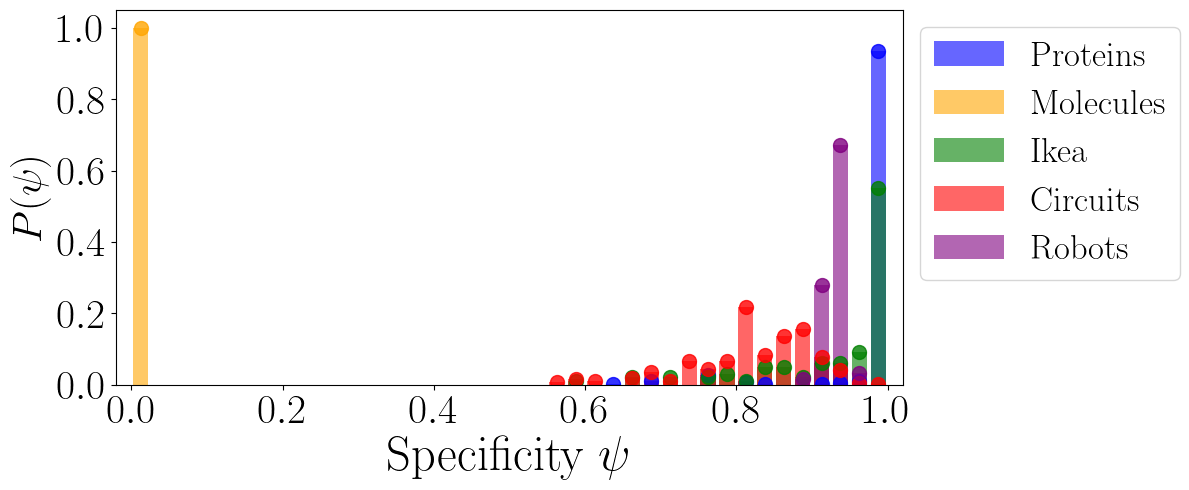

In [ ]:
csfont = {'fontname':'Times New Roman'}
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times New Roman']})
rc('text', usetex=True)

plt.figure(figsize=(12, 5))

# Filter and plot bars for Proteins
non_zero_prot = prot_y > 0
plt.bar(prot_x[non_zero_prot], prot_y[non_zero_prot], width=0.02, label='Proteins', color='blue', alpha=0.6)

# Filter and plot bars for Molecules
non_zero_mol = mol_y > 0
plt.bar(mol_x[non_zero_mol], mol_y[non_zero_mol], width=0.02, label='Molecules', color='orange', alpha=0.6)

# Filter and plot bars for Ikea
non_zero_ikea = ikea_y > 0
plt.bar(ikea_x[non_zero_ikea], ikea_y[non_zero_ikea], width=0.02, label='Ikea', color='green', alpha=0.6)

# Filter and plot bars for Circuits
non_zero_circuit = circuit_y > 0
plt.bar(circuit_x[non_zero_circuit], circuit_y[non_zero_circuit], width=0.02, label='Circuits', color='red', alpha=0.6)

# Filter and plot bars for Robots
non_zero_robot = robot_y > 0
plt.bar(robot_x[non_zero_robot], robot_y[non_zero_robot], width=0.02, label='Robots', color='purple', alpha=0.6)

# Add dots at the top of the bars
plt.scatter(prot_x[non_zero_prot], prot_y[non_zero_prot], color='blue', s=100, alpha=0.8)
plt.scatter(mol_x[non_zero_mol], mol_y[non_zero_mol], color='orange', s=100, alpha=0.8)
plt.scatter(ikea_x[non_zero_ikea], ikea_y[non_zero_ikea], color='green', s=100, alpha=0.8)
plt.scatter(circuit_x[non_zero_circuit], circuit_y[non_zero_circuit], color='red', s=100, alpha=0.8)
plt.scatter(robot_x[non_zero_robot], robot_y[non_zero_robot], color='purple', s=100, alpha=0.8)

plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.xlabel(r'Specificity $\psi$', fontsize=35)
plt.ylabel(r'$P(\psi)$', fontsize=30)
plt.xlim(-.02, 1.02)
plt.ylim(0, 1.05)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=25)
plt.tight_layout()
plt.savefig('/Users/glover.co/CCNR Dropbox/Success Team/Glover, Cory/network_design/drafts/Network-Design-March-2025-/v10/figs/specificity_distributions.png', bbox_inches='tight', dpi=1200)
plt.show()


In [61]:
with open('../stats/proteins/self_assembly.txt','r') as f:
    prot_sa = f.readlines()
prot_sa = [p.strip() for p in prot_sa]
prot_sa = [0 if p == 'False' else 1 for p in prot_sa]
prot_sa = np.array(prot_sa)
with open('../stats/molecules/self_assembly.txt','r') as f:
    mol_sa = f.readlines()
mol_sa = [m.strip() for m in mol_sa]
mol_sa = [0 if m == 'False' else 1 for m in mol_sa]
mol_sa = np.array(mol_sa)
with open('../stats/robots/self_assembly.txt','r') as f:
    robot_sa = f.readlines()
robot_sa = [r.strip() for r in robot_sa]
robot_sa = [0 if r == 'False' else 1 for r in robot_sa]
robot_sa = np.array(robot_sa)
with open('../stats/circuits/self_assembly.txt','r') as f:
    circuit_sa = f.readlines()
circuit_sa = [c.strip() for c in circuit_sa]
circuit_sa = [0 if c == 'False' else 1 for c in circuit_sa]
circuit_sa = np.array(circuit_sa)
with open('../stats/Ikea/self_assembly.txt','r') as f:
    ikea_sa = f.readlines()
ikea_sa = [i.strip() for i in ikea_sa]
ikea_sa = [0 if i == 'False' else 1 for i in ikea_sa]
ikea_sa = np.array(ikea_sa)

In [38]:
np.where(prot_sa==0)[0] + 1

array([ 11,  26,  30,  43,  46,  48,  52,  56,  57,  60,  64,  73,  74,
        75,  77,  87,  88,  90, 117, 120, 132, 153, 158, 161, 171, 182,
       185, 190, 201, 205, 209, 238, 241, 254, 265, 272, 289, 317, 320,
       322, 326, 334, 351, 352, 362, 364, 365, 369, 379, 380, 385, 387,
       394, 398, 410, 415, 418, 443, 499, 503, 507, 578, 585, 587])

In [55]:
prot_sa_y, prot_x = np.histogram(prot_sa, bins=2, range=(0,1))
mol_sa_y, mol_x = np.histogram(mol_sa, bins=2, range=(0,1))
ikea_sa_y, ikea_x = np.histogram(ikea_sa, bins=2, range=(0,1))
circuit_sa_y, circuit_x = np.histogram(circuit_sa, bins=2, range=(0,1))
robot_sa_y, robot_x = np.histogram(robot_sa, bins=2, range=(0,1))
prot_sa_y = prot_sa_y / np.sum(prot_sa_y)
mol_sa_y = mol_sa_y / np.sum(mol_sa_y)
ikea_sa_y = ikea_sa_y / np.sum(ikea_sa_y)
circuit_sa_y = circuit_sa_y / np.sum(circuit_sa_y)
robot_sa_y = robot_sa_y / np.sum(robot_sa_y)

In [56]:
prot_x = (prot_x[:-1] + prot_x[1:]) / 2
mol_x = (mol_x[:-1] + mol_x[1:]) / 2
ikea_x = (ikea_x[:-1] + ikea_x[1:]) / 2
circuit_x = (circuit_x[:-1] + circuit_x[1:]) / 2
robot_x = (robot_x[:-1] + robot_x[1:]) / 2

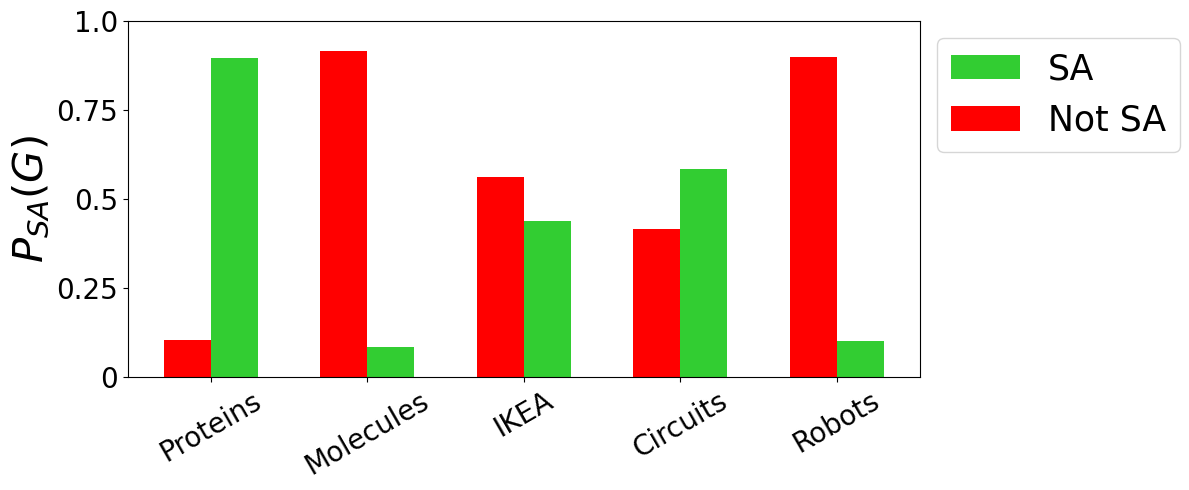

In [63]:
plt.figure(figsize=(12, 5))
# Make bar plots for each dataset side by side
plt.bar(.3, prot_sa_y[1], width=0.3, color='#32CD32', label='SA', alpha=1)
plt.bar(0, prot_sa_y[0], width=0.3, label='Not SA', color='red', alpha=1)
plt.bar(1, mol_sa_y[0], width=0.3, color='red', alpha=1)
plt.bar(1.3, mol_sa_y[1], width=0.3, color='#32CD32', alpha=1)
plt.bar(2, ikea_sa_y[0], width=0.3, color='red', alpha=1)
plt.bar(2.3, ikea_sa_y[1], width=0.3, color='#32CD32', alpha=1)
plt.bar(3, circuit_sa_y[0], width=0.3, color='red', alpha=1)
plt.bar(3.3, circuit_sa_y[1], width=0.3, color='#32CD32', alpha=1)
plt.bar(4, robot_sa_y[0], width=0.3, color='red', alpha=1)
plt.bar(4.3, robot_sa_y[1], width=0.3, color='#32CD32', alpha=1)
# plt.plot(.3, prot_max_div_perc, '*', color='black', markersize=15, label='Max. Diversity') 
# plt.plot(1.3, mol_max_div_perc, '*', color='black', markersize=15)
# plt.plot(2.3, ikea_max_div_perc, '*', color='black', markersize=15)
# plt.plot(3.3, circuit_max_div_perc, '*', color='black', markersize=15)
# plt.plot(4.3, robots_max_div_perc, '*', color='black', markersize=15)
plt.xticks([0.15, 1.15, 2.15, 3.15, 4.15], ['Proteins', 'Molecules', 'IKEA', 'Circuits', 'Robots'], fontsize=20,rotation=30)
plt.yticks(ticks=[0,.25,.5,.75,1.0], labels=[0,.25,.5,.75,1.0], fontsize=20)
plt.ylabel(r'$P_{SA}(G)$', fontsize=30)
plt.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=25)
plt.tight_layout()
plt.savefig('/Users/glover.co/CCNR Dropbox/Success Team/Glover, Cory/network_design/drafts/Network-Design-March-2025-/v10/figs/self_assembly.pdf', bbox_inches='tight', dpi=300)


In [46]:
circuit_sa

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [7]:
import json 
with open('/Users/glover.co/Documents/laszlo/NetDesign/data/proteins/human/treefiles/CPX-1919_tree.json', 'r') as f:
    tree_data = json.load(f)

In [14]:
target = nx.read_edgelist('../data/proteins/human/edgefiles/CPX-1919.edge',nodetype=int)
X = np.loadtxt('../data/proteins/human/Xfiles/X_CPX-1919.txt')
if X.ndim == 1:
    X = X.reshape(len(X),1)
capacity = at.extract_deg_cap(target, X).reshape(-1)
O = at.extract_O(target, X)

In [16]:
trees = []
for tree_dict in tree_data:
    T = mcmc.AssemblyTree(target, X, O, capacity, multiedge=False)
    T = at.load_tree(tree_dict, T)
    trees.append(T)

In [20]:
for i, T in enumerate(trees):
    print(T.Tree.depth(),
                     len(T.Tree.leaves()),
                     T.Tree.all_nodes())

3 11 [Node(tag=0, identifier=0, data=<mcmc.AssemblyNode object at 0x31fafb610>), Node(tag=13, identifier=13, data=<mcmc.AssemblyNode object at 0x105016890>), Node(tag=55, identifier=55, data=<mcmc.AssemblyNode object at 0x3206060d0>), Node(tag=60, identifier=60, data=<mcmc.AssemblyNode object at 0x320822090>), Node(tag=86, identifier=86, data=<mcmc.AssemblyNode object at 0x320821110>), Node(tag=87, identifier=87, data=<mcmc.AssemblyNode object at 0x3206a9490>), Node(tag=82, identifier=82, data=<mcmc.AssemblyNode object at 0x32099ded0>), Node(tag=73, identifier=73, data=<mcmc.AssemblyNode object at 0x32099d290>), Node(tag=74, identifier=74, data=<mcmc.AssemblyNode object at 0x3209b6910>), Node(tag=81, identifier=81, data=<mcmc.AssemblyNode object at 0x31fed2f10>), Node(tag=84, identifier=84, data=<mcmc.AssemblyNode object at 0x31fed3250>), Node(tag=85, identifier=85, data=<mcmc.AssemblyNode object at 0x3206070d0>), Node(tag=83, identifier=83, data=<mcmc.AssemblyNode object at 0x31fd84f9

In [18]:
T.Tree.get_node(0).data.p

[0.842]

In [29]:
np.loadtxt('../data/proteins/human/treefiles/CPX-1919_tree_stats.txt',skiprows=1,delimiter=',')[0].flatten()

array([1.00000000e+00, 3.00000000e+00, 2.89279826e+04])

In [5]:
ikea_df = pd.read_csv('../stats/Ikea/newest_assembly_stats.csv',index_col=False)
protein_df = pd.read_csv('../stats/proteins/newest_assembly_stats.csv',index_col=False)
molecule_df = pd.read_csv('../stats/molecules/newest_assembly_stats.csv',index_col=False)
robot_df = pd.read_csv('../stats/robots/newest_assembly_stats.csv',index_col=False)
circuit_df = pd.read_csv('../stats/circuits/newest_assembly_stats.csv',index_col=False)

In [6]:
# Make columns value the same for all rows of the same name
uniq_prot = protein_df['name'].unique()
for name in uniq_prot:
    rows = protein_df['name'] == name
    protein_df.loc[rows, 'self_assembly_probability'] = protein_df.loc[rows, 'self_assembly_probability'].max()

uniq_mol = molecule_df['name'].unique()
for name in uniq_mol:
    rows = molecule_df['name'] == name
    molecule_df.loc[rows, 'self_assembly_probability'] = molecule_df.loc[rows, 'self_assembly_probability'].max()

uniq_ikea = ikea_df['name'].unique()
for name in uniq_ikea:
    rows = ikea_df['name'] == name
    ikea_df.loc[rows, 'self_assembly_probability'] = ikea_df.loc[rows, 'self_assembly_probability'].max()

uniq_circuit = circuit_df['name'].unique()
for name in uniq_circuit:
    rows = circuit_df['name'] == name
    circuit_df.loc[rows, 'self_assembly_probability'] = circuit_df.loc[rows, 'self_assembly_probability'].max()

uniq_robot = robot_df['name'].unique()
for name in uniq_robot:
    rows = robot_df['name'] == name
    robot_df.loc[rows, 'self_assembly_probability'] = robot_df.loc[rows, 'self_assembly_probability'].max()

In [7]:
protein_df = protein_df[protein_df['tree_depth'] != np.nan]
molecule_df = molecule_df[molecule_df['tree_depth'] != np.nan]
ikea_df = ikea_df[ikea_df['tree_depth'] != np.nan]
circuit_df = circuit_df[circuit_df['tree_depth'] != np.nan]
robot_df = robot_df[robot_df['tree_depth'] != np.nan]

In [8]:

prot_sa = protein_df.groupby('name')['self_assembly_probability'].max()
prot_ga = protein_df[protein_df['self_assembly_probability'] != True].groupby('name')['guided_assembly_probability'].max()
num_prot_sa = prot_sa[prot_sa == True].count()
num_prot_ga = prot_ga[prot_ga == 1].count()
num_prot_total = len(prot_sa)
prot_sa_perc = num_prot_sa / num_prot_total
prot_ga_perc = num_prot_ga / num_prot_total
prot_non_sa_perc = 1 - prot_sa_perc - prot_ga_perc

mol_sa = molecule_df.groupby('name')['self_assembly_probability'].max()
mol_ga = molecule_df[molecule_df['self_assembly_probability'] != True].groupby('name')['guided_assembly_probability'].max()
num_mol_sa = mol_sa[mol_sa == True].count()
num_mol_ga = mol_ga[mol_ga == 1].count()
num_mol_total = len(mol_sa)
mol_sa_perc = num_mol_sa / num_mol_total
mol_ga_perc = num_mol_ga / num_mol_total
mol_non_sa_perc = 1 - mol_sa_perc - mol_ga_perc

ikea_sa = ikea_df.groupby('name')['self_assembly_probability'].max()
ikea_ga = ikea_df[ikea_df['self_assembly_probability'] != True].groupby('name')['guided_assembly_probability'].max()
num_ikea_sa = ikea_sa[ikea_sa == True].count()
num_ikea_ga = ikea_ga[ikea_ga == 1].count()
num_ikea_total = len(ikea_sa)
ikea_sa_perc = num_ikea_sa / num_ikea_total
ikea_ga_perc = num_ikea_ga / num_ikea_total
ikea_non_sa_perc = 1 - ikea_sa_perc - ikea_ga_perc

circuit_sa = circuit_df.groupby('name')['self_assembly_probability'].max()
circuit_ga = circuit_df[circuit_df['self_assembly_probability'] != True].groupby('name')['guided_assembly_probability'].max()
num_circuit_sa = circuit_sa[circuit_sa == True].count()
num_circuit_ga = circuit_ga[circuit_ga == 1].count()
num_circuit_total = len(circuit_sa)
circuit_sa_perc = num_circuit_sa / num_circuit_total
circuit_ga_perc = num_circuit_ga / num_circuit_total
circuit_non_sa_perc = 1 - circuit_sa_perc - circuit_ga_perc

robot_sa = robot_df.groupby('name')['self_assembly_probability'].max()
robot_ga = robot_df[robot_df['self_assembly_probability'] != True].groupby('name')['guided_assembly_probability'].max()
num_robot_sa = robot_sa[robot_sa == True].count()
num_robot_ga = robot_ga[robot_ga == 1].count()
num_robot_total = len(robot_sa)
robot_sa_perc = num_robot_sa / num_robot_total
robot_ga_perc = num_robot_ga / num_robot_total
robot_non_sa_perc = 1 - robot_sa_perc - robot_ga_perc




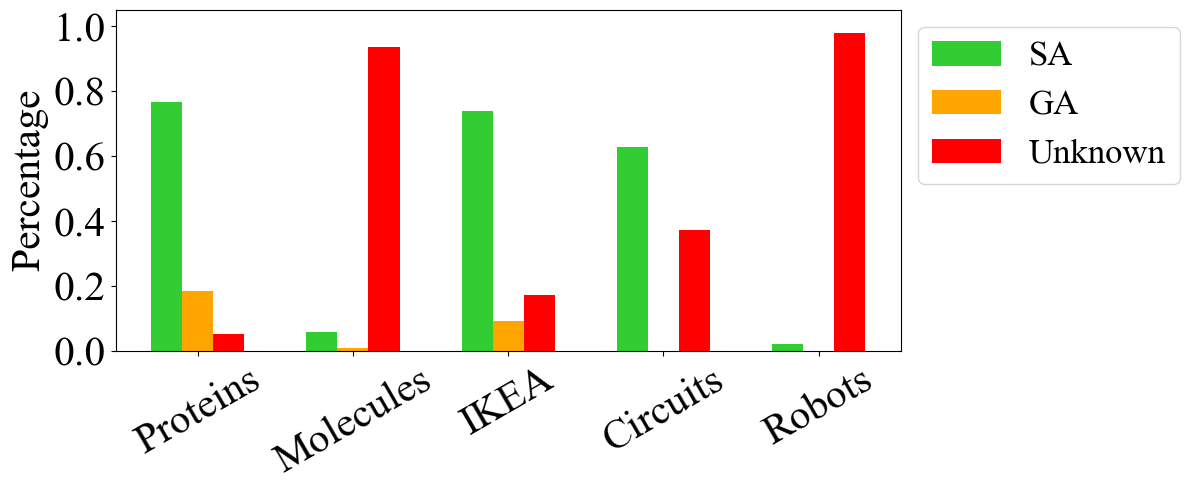

In [9]:
csfont = {'fontname':'Times New Roman'}
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times New Roman']})
rc('text', usetex=False)

plt.figure(figsize=(12, 5))

plt.bar(0, prot_sa_perc, width=0.2, color='#32CD32', label='SA', alpha=1)
plt.bar(.2, prot_ga_perc, width=0.2, color='orange', label='GA', alpha=1)
plt.bar(.4, prot_non_sa_perc, width=0.2, label='Unknown', color='red', alpha=1)

plt.bar(1, mol_sa_perc, width=0.2, color='#32CD32', alpha=1)
plt.bar(1.2, mol_ga_perc, width=0.2, color='orange', alpha=1)
plt.bar(1.4, mol_non_sa_perc, width=0.2, color='red', alpha=1)

plt.bar(2, ikea_sa_perc, width=0.2, color='#32CD32', alpha=1)
plt.bar(2.2, ikea_ga_perc, width=0.2, color='orange', alpha=1)
plt.bar(2.4, ikea_non_sa_perc, width=0.2, color='red', alpha=1)

plt.bar(3, circuit_sa_perc, width=0.2, color='#32CD32', alpha=1)
plt.bar(3.2, circuit_ga_perc, width=0.2, color='orange', alpha=1)
plt.bar(3.4, circuit_non_sa_perc, width=0.2, color='red', alpha=1)

plt.bar(4, robot_sa_perc, width=0.2, color='#32CD32', alpha=1)
plt.bar(4.2, robot_ga_perc, width=0.2, color='orange', alpha=1)
plt.bar(4.4, robot_non_sa_perc, width=0.2, color='red', alpha=1)

plt.xticks([0.2, 1.2, 2.2, 3.2, 4.2], ['Proteins', 'Molecules', 'IKEA', 'Circuits', 'Robots'], fontsize=30,rotation=30)
plt.yticks(fontsize=30)
# plt.xlabel(r'Specificity $\psi$', fontsize=35)
plt.ylabel(r'Percentage', fontsize=30)
# plt.xlim(-.02, 1.02)
plt.ylim(0, 1.05)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=25)
plt.tight_layout()
# plt.savefig('/Users/glover.co/CCNR Dropbox/Success Team/Glover, Cory/network_design/drafts/Network-Design-March-2025-/v10/figs/guided_assembly.png', bbox_inches='tight', dpi=1200)
plt.show()


In [14]:
protein_df = protein_df[protein_df['self_assembly_probability'] != True]
molecule_df = molecule_df[molecule_df['self_assembly_probability'] != True]
ikea_df = ikea_df[ikea_df['self_assembly_probability'] != True]
circuit_df = circuit_df[circuit_df['self_assembly_probability'] != True]
robot_df = robot_df[robot_df['self_assembly_probability'] != True]
uniq_prot = protein_df['name'].unique()
prot_ga_p = []
for name in uniq_prot:
    rows = protein_df['name'] == name
    prot_ga_p.append(protein_df.loc[rows, 'guided_assembly_probability'].max())
prot_ga_p = np.array(prot_ga_p)

uniq_mol = molecule_df['name'].unique()
mol_ga_p = []
for name in uniq_mol:
    rows = molecule_df['name'] == name
    mol_ga_p.append(molecule_df.loc[rows, 'guided_assembly_probability'].max())
mol_ga_p = np.array(mol_ga_p)

uniq_ikea = ikea_df['name'].unique()
ikea_ga_p = []
for name in uniq_ikea:
    rows = ikea_df['name'] == name
    ikea_ga_p.append(ikea_df.loc[rows, 'guided_assembly_probability'].max())
ikea_ga_p = np.array(ikea_ga_p)

uniq_circuit = circuit_df['name'].unique()
circuit_ga_p = []
for name in uniq_circuit:
    rows = circuit_df['name'] == name
    circuit_ga_p.append(circuit_df.loc[rows, 'guided_assembly_probability'].max())

circuit_ga_p = np.array(circuit_ga_p)

uniq_robot = robot_df['name'].unique()
robot_ga_p = []
for name in uniq_robot:
    rows = robot_df['name'] == name
    robot_ga_p.append(robot_df.loc[rows, 'guided_assembly_probability'].max())
robot_ga_p = np.array(robot_ga_p)

In [15]:
prot_y, prot_x = np.histogram(prot_ga_p, bins=40, range=(0,1))
mol_y, mol_x = np.histogram(mol_ga_p, bins=40, range=(0,1))
ikea_y, ikea_x = np.histogram(ikea_ga_p, bins=40, range=(0,1))
circuit_y, circuit_x = np.histogram(circuit_ga_p, bins=40, range=(0,1))
robot_y, robot_x = np.histogram(robot_ga_p, bins=40, range=(0,1))
prot_y = prot_y / np.sum(prot_y)
mol_y = mol_y / np.sum(mol_y)
ikea_y = ikea_y / np.sum(ikea_y)
circuit_y = circuit_y / np.sum(circuit_y)
robot_y = robot_y / np.sum(robot_y)

/var/folders/8t/4z1vq2xd5790h0y5jrvphttr0000gp/T/ipykernel_44922/2576452970.py:10: RuntimeWarning: invalid value encountered in divide
  robot_y = robot_y / np.sum(robot_y)


In [16]:
prot_x = (prot_x[:-1] + prot_x[1:]) / 2
mol_x = (mol_x[:-1] + mol_x[1:]) / 2
ikea_x = (ikea_x[:-1] + ikea_x[1:]) / 2
circuit_x = (circuit_x[:-1] + circuit_x[1:]) / 2
robot_x = (robot_x[:-1] + robot_x[1:]) / 2

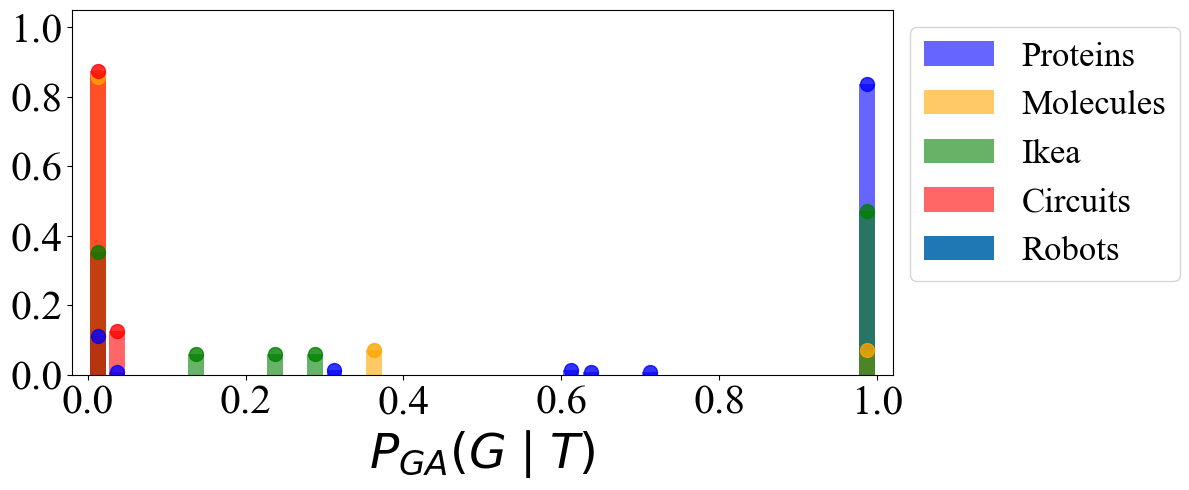

In [17]:
csfont = {'fontname':'Times New Roman'}
from matplotlib import rc
# rc('font',**{'family':'serif','serif':['Times New Roman']})
# rc('text', usetex=False)

plt.figure(figsize=(12, 5))

# Filter and plot bars for Proteins
non_zero_prot = prot_y > 0
plt.bar(prot_x[non_zero_prot], prot_y[non_zero_prot], width=0.02, label='Proteins', color='blue', alpha=0.6)

# Filter and plot bars for Molecules
non_zero_mol = mol_y > 0
plt.bar(mol_x[non_zero_mol], mol_y[non_zero_mol], width=0.02, label='Molecules', color='orange', alpha=0.6)

# Filter and plot bars for Ikea
non_zero_ikea = ikea_y > 0
plt.bar(ikea_x[non_zero_ikea], ikea_y[non_zero_ikea], width=0.02, label='Ikea', color='green', alpha=0.6)

# Filter and plot bars for Circuits
non_zero_circuit = circuit_y > 0
plt.bar(circuit_x[non_zero_circuit], circuit_y[non_zero_circuit], width=0.02, label='Circuits', color='red', alpha=0.6)

# Filter and plot bars for Robots
non_zero_robot = robot_y > 0
plt.bar(robot_x[non_zero_robot], robot_y[non_zero_robot], width=0.02, label='Robots', color='purple', alpha=0.6)

# Add dots at the top of the bars
plt.scatter(prot_x[non_zero_prot], prot_y[non_zero_prot], color='blue', s=100, alpha=0.8)
plt.scatter(mol_x[non_zero_mol], mol_y[non_zero_mol], color='orange', s=100, alpha=0.8)
plt.scatter(ikea_x[non_zero_ikea], ikea_y[non_zero_ikea], color='green', s=100, alpha=0.8)
plt.scatter(circuit_x[non_zero_circuit], circuit_y[non_zero_circuit], color='red', s=100, alpha=0.8)
plt.scatter(robot_x[non_zero_robot], robot_y[non_zero_robot], color='purple', s=100, alpha=0.8)

plt.xticks(fontsize=30)
plt.yticks(fontsize=30)
plt.xlabel(r'$P_{GA}(G\mid T)$', fontsize=35)
# plt.ylabel(r'$P$', fontsize=30)
plt.xlim(-.02, 1.02)
plt.ylim(0, 1.05)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=25)
plt.tight_layout()
plt.savefig('/Users/glover.co/CCNR Dropbox/Success Team/Glover, Cory/network_design/drafts/Network-Design-March-2025-/v10/figs/ga_distributions.png', bbox_inches='tight', dpi=1200)
plt.show()

In [77]:
prot_ga

name
CPX-10041    1.0
CPX-101      1.0
CPX-10221    1.0
CPX-10241    1.0
CPX-10261    1.0
            ... 
CPX-975      1.0
CPX-977      1.0
CPX-9801     1.0
CPX-984      1.0
CPX-995      1.0
Name: guided_assembly_probability, Length: 619, dtype: float64